</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>Práctica 1:
        </h2>
        <h1 style="margin-top: -10px;">
            Análisis, procesamiento y validación
        </h1>
    </div>
    <div style="width: 50%; text-align: right;">
        <div style="display: flex; justify-content: space-between; align-items: flex-start; margin-top: 30px;">
            <div style="width: 20%;"></div>
            <div style="width: 80%; border-left: 2px solid #555555; padding-left: 20px;">
                <div style="margin-bottom: 20px;">
                    <p style="margin: 0; font-size: 1.4em; font-weight: bold;">
                        Minería de Datos, 2026-27
                    </p>
                </div>
                <div style="margin-top: 8px; text-align: right;">
                    <span style="font-size: 1em; color: #D0D0D0;">
                        José Antonio Gámez Martín
                    </span>
                    <a href="mailto:Jose.Gamez@uclm.es" style="text-decoration: none; color: #888888; font-size: 0.8em; padding-left: 15px;">
                        ✉ Jose.Gamez@uclm.es
                    </a>
                </div>
                <div style="margin-top: 8px; text-align: right;">
                    <span style="font-size: 1em; color: #D0D0D0;">
                        Pablo Torrijos Arenas
                    </span>
                    <a href="mailto:Pablo.Torrijos@uclm.es" style="text-decoration: none; color: #888888; font-size: 0.8em; padding-left: 15px;">
                        ✉ Pablo.Torrijos@uclm.es
                    </a>
                </div>
                </div>
            </div>
        </div>
    </div>
</div>

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #B30033; font-size: 1.5em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1.4em; font-weight: bold">
            Estudiantes
        </h3>
    </div>
    <ul style="list-style-type: none; padding-left: 28px; margin: 0;  font-size: 1.1em">
        <li>Guillermo Morcillo Conchán</li>
        <li>David Gómez Aniorte</li>
    </ul>

</div>

## 1. Introducción

El objetivo de esta práctica es aplicar las técnicas de un flujo de trabajo de **minería de datos** para resolver un problema de **clasificación supervisada**. Se analizará un conjunto de datos sobre el rendimiento y la actividad de estudiantes universitarios para predecir la probabilidad de abandono de sus estudios.

El desarrollo abarcará desde el **análisis exploratorio** de los datos y su **preprocesamiento**, hasta el **entrenamiento** de un modelo y su **validación** robusta. 

El rendimiento de los modelos se evaluará en una competición privada en Kaggle, que abarcará esta Práctica 1 y la Práctica 2 (selección de modelos).

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

## 2. Carga y visualización de los datos

Se proporciona un conjunto de datos sintético que simula el rendimiento académico y la interacción de estudiantes durante su primer año. Los datos contienen una variedad de tipos de variables, valores faltantes y otros artefactos que deberán ser gestionados.

Comenzamos importando las librerías necesarias y cargando los conjuntos de datos de entrenamiento (`train`) y de prueba (`test`) para poder examinarlos:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


pd.set_option('display.max_columns', None)

df_train = pd.read_csv('uclm_student_train.csv')
df_train

,id,nombre,nacimiento,provincia,residencia_id,titulacion,via_acceso,nota_acceso,bachillerato,trabaja,horas_trabajo,modalidad,creditos_a1,superados_a1,nota_s1,satisfaccion,horas_moodle,uso_biblioteca,eventos,tutorias,comentarios,numero_fav,talla_zapato,color_fav,meses_matriculado,grupo_trabajo,abandono
0,CR-2018-BCG465,Berta Calderon Giménez,1995-12-02,Albacete,E1-P00-H12,Bellas Artes,Ciclo Formativo de Grado Superior,"7,09",SOCIAL,0,NaN,Tiempo completo,60,60,"8,57","4,15",~5.5 horas,3,0,2,NaN,46,40,Beige pálido,12,GR007497,0
1,TO-2014-CFB931,Celestina Font Barranco,1996-02-25,Ciudad Real,E1-P02-H17,Doble Grado Derecho-ade,PAU / Bachillerato,"6,79",Humanidades,0,NaN,Tiempo completo,60,24,"4,75",2.51,9.1,8,1,2,Situacion academica estable. Respeta las regla...,69,35,Marrón claro,6,GR003647,0
2,CR-2014-ICS169,Irene Carranza Salvador,1968-08-02,Ciudad Real,E1-P00-H16,Derecho,Mayores de 25 años,"5,00",HUMANIDADES,1,40.0,Tiempo completo,60,42,6.19,"3,11","~3,9 horas",9,0,0,Ausencias injustificadas en seminarios. No int...,16,40,Violeta claro,5,GR003040,1
3,AB-2017-ECG641,Elodia Carmona Gisbert,2000-02-10,Albacete,NaN,Medicina,Ciclo Formativo de Grado Superior,"6,41",Ciencias Puras,0,NaN,Tiempo completo,60,42,"5,14",2.51,~8.2 horas,7,3,3,Uso habitual de la plataforma Moodle. Uso habi...,68,39,Rosa oscuro,6,GR006101,0
4,CR-2013-SGC508,Sara Guillén Cornejo,1996-01-29,Ciudad Real,NaN,Ingeniería Informática,PAU / Bachillerato,"9,05",cientifico,0,NaN,Tiempo completo,60,6,"2,68","1,16",~6.2 horas,1,2,0,Uso habitual de la plataforma Moodle. Interacc...,95,37,Violeta intenso,6,GR002005,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41081,TO-2018-GDM832,Gala de Meléndez,2000-07-15,Toledo,NaN,Comunicación Audiovisual,Ciclo Formativo de Grado Superior,"7,42",Económico,0,NaN,Tiempo completo,60,48,"6,55","3,29",~5.4 horas,4,2,0,Barreras de conciliacion con el desplazamiento...,89,36,Salmón claro,12,GR008301,0
41082,CU-2014-MCB088,Maximino Campoy Benítez,1996-11-20,Cuenca,NaN,Derecho,PAU / Bachillerato,"11,08",ECONÓMICO,0,NaN,Tiempo parcial,36,36,"7,31","3,58",~7.4 horas,0,2,1,Cumple siempre con trabajos. Contacta por corr...,13,47,Índigo pálido,6,GR003339,0
41083,CR-2015-XL601,Xavier Landa-Galván,1969-04-11,Álava,NaN,Ingeniería Mecánica,Mayores de 25 años,"7,78",ciencias puras,1,25.0,Tiempo completo,60,60,"5,65","2,67",~9.2 horas,5,2,2,No asiste a seminarios. Participacion moderada...,58,43,Marrón oscuro,6,GR004337,1
41084,CR-2012-BOI015,Begoña Olivares Iriarte,1995-01-31,Toledo,NaN,Historia del Arte,PAU / Bachillerato,7.74,Humanidades,0,NaN,Tiempo parcial,36,30,"7,15","4,13",~9.1 horas,6,3,2,NaN,23,34,Violeta pálido,6,GR000405,0


In [2]:
df_test = pd.read_csv('uclm_student_test.csv')
df_test

,id,nombre,nacimiento,provincia,residencia_id,titulacion,via_acceso,nota_acceso,bachillerato,trabaja,horas_trabajo,modalidad,creditos_a1,superados_a1,nota_s1,satisfaccion,horas_moodle,uso_biblioteca,eventos,tutorias,comentarios,numero_fav,talla_zapato,color_fav,meses_matriculado,grupo_trabajo
0,CU-2019-RFV844,Remigio Ferrera Vázquez,2001-03-27,Cuenca,NaN,Doble Grado Derecho-ade,PAU / Bachillerato,"8,68",SOCIAL,0,NaN,Tiempo completo,60,48,6.80,"3,46",~6.7 horas,3,2,2,Incomparecencia en las sesiones de seguimiento...,55,39,Ocre claro,12,GR009189
1,AB-2020-RR266,Rosalía Rojas,2002-07-23,Ciudad Real,E1-P03-H14,Comunicación Audiovisual,Ciclo Formativo de Grado Superior,"8,27",SOCIAL,1,40.0,Tiempo completo,60,60,"8,07","3,92",5.5,11,2,1,Uso del entorno virtual sin particularidades. ...,35,38,Granate,8,GR009871
2,CR-2019-FFC269,Felicia Ferreras Colom,2002-01-05,Ciudad Real,NaN,Criminología,Ciclo Formativo de Grado Superior,"5,00",humanidades,0,NaN,Tiempo completo,60,60,8.64,"4,57",~6.5 horas,2,3,2,Gestion ejemplar de el cuidado familiar. Adher...,22,36,Caqui oscuro,12,GR008954
3,AB-2020-OFC312,Ofelia Ferrández Carranza,2002-12-14,Badajoz,NaN,Administración y Dirección de Empresas,PAU / Bachillerato,"9,10",humanidades,1,40.0,Tiempo completo,60,30,"4,45","2,25",7.4,3,2,1,Uso del entorno virtual sin particularidades. ...,6,40,Lima oscuro,10,GR009879
4,CR-2019-MRP759,Máxima Rosselló Palomares,2001-10-27,Ciudad Real,NaN,Ingeniería Mecánica,PAU / Bachillerato,8.61,Ciencias,0,NaN,Tiempo completo,60,24,"2,95","1,41",~8.3 horas,3,0,1,incidencias registradas en el programa de ment...,14,37,Turquesa intenso,8,GR009056
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11229,CU-2019-FP888,Fanny Pedrero,2001-02-23,Cuenca,NaN,Maestro en Educación Primaria,Ciclo Formativo de Grado Superior,"6,48",ECONÓMICO,0,NaN,Tiempo completo,60,60,8.53,4.33,~2.3 horas,0,3,2,No supera los minimos de la materia basica. Ad...,54,38,Magenta intenso,6,GR009181
11230,CU-2019-MBT460,Miriam Baeza Torralba,2001-04-12,Girona,NaN,Doble Grado Ade-estudios Internacionales,PAU / Bachillerato,"8,58",Económico,0,NaN,Tiempo parcial,30,12,"4,30","2,33",~6.7 horas,5,2,0,NaN,15,38,Plata,11,GR009205
11231,CR-2019-EJF437,Enrique Juliá Fabra,1995-01-26,Ciudad Real,E1-P02-H11,Derecho,Titulado universitario,"8,15",economico,0,NaN,Tiempo completo,60,60,"8,30","4,20","4,1h",4,4,3,NaN,24,46,Magenta,11,GR008919
11232,CR-2019-CAP408,Chema Alejo Peláez Mas,2001-07-08,NaN,E2-P02-H09,"Lenguas y Literaturas Modernas, Francés-inglés",Ciclo Formativo de Grado Superior,"7,22",Social,0,NaN,Tiempo completo,60,60,"8,68","4,67",~6.5 horas,6,1,1,Se ofrece como referente para estudiantes de n...,23,44,Negro,12,GR008774


Las variables disponibles son:
`id`, `nombre`, `nacimiento`, `provincia`, `residencia_id`, `titulacion`, `via_acceso`, `nota_acceso`, `bachillerato`, `trabaja`, `horas_trabajo`, `modalidad`, `creditos_a1`, `superados_a1`, `nota_s1`, `satisfaccion`, `horas_moodle`, `uso_biblioteca`, `eventos`, `tutorias`, `comentarios`, `numero_fav`, `talla_zapato`, `color_fav`, `meses_matriculado`, `grupo_trabajo`, `abandono`.

La variable objetivo es `abandono`, que es binaria:
* **1**: El estudiante abandona los estudios.
* **0**: El estudiante continúa.

Se puede observar cómo hay variables categóricas, numéricas, fechas, texto, valores faltantes... Esto requerirá de un análisis exploratorio y un preprocesamiento.

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

## 3. Flujo de Trabajo y Requisitos

El desarrollo de la práctica deberá seguir las siguientes etapas:


### 3.1. Análisis Exploratorio de Datos (EDA)

Se debe realizar un análisis inicial para comprender la naturaleza de los datos. Este análisis debe incluir:
* Distribución de la variable objetivo (`abandono`).
* Análisis de valores faltantes.
* Distribución de las variables numéricas y categóricas, valores únicos, outliers...
* Identificación de valores atípicos.
* Relaciones entre las variables y la variable objetivo.

Las conclusiones de este análisis deben servir para justificar las decisiones tomadas en la siguiente etapa.


### 3.2. Preprocesamiento de Datos

Esta etapa es fundamental para preparar los datos antes de la modelización. Las tareas incluyen la imputación de valores faltantes, la codificación de variables categóricas, la ingeniería de características (ej. creación de nuevas variables a partir de las existentes), el escalado de datos o incluso eliminar variables que no nos aporten información.

Este proceso debe de ir totalmente ligado al EDA. Las conclusiones que hayamos sacado en el estudio son las que nos deben guiar en este paso. Del mismo modo, al preprocesar los datos y entrenar los modelos podemos sacar nuevas conclusiones que nos permitan entender mejor los datos (como habéis visto en **CRISP-DM**):

<img src="https://upload.wikimedia.org/wikipedia/commons/b/b9/CRISP-DM_Process_Diagram.png" alt="Diagrama de Proceso CRISP-DM" width="550"/>

**Requisito obligatorio**: Todo el proceso de transformación de datos **debe** encapsularse en `Pipelines` de `scikit-learn`. En la práctica, además de mantener una mayor claridad y estructura en el código, esto nos ayudará a evitar fugas de datos.


### 3.3. Modelización y Validación

Se debe entrenar y evaluar correctamente **al menos un algoritmo** (ej. Árboles de Decisión, Naive Bayes, etc.). En esta práctica no es importante usar el mejor modelo posible (eso vendrá en la Práctica 2), sino analizar, preparar y evaluar bien los datos.

**Requisito obligatorio**: La evaluación y comparación de los modelos **debe** realizarse mediante una estrategia de **validación cruzada**. Además, es importante tener en cuenta distintas **métricas** para evaluar nuestro modelo.


### 3.4. Predicción y Evaluación

El modelo final se puede utilizar para generar predicciones sobre el conjunto `uclm_student_test.csv`. Esto es recomendable, pero no es obligatorio en esta práctica (lo será en la Práctica 2).

El fichero de predicciones deberá seguir el formato especificado en `sample_submission.csv`:

In [3]:
df_kaggle = pd.read_csv('sample_submission.csv')
df_kaggle

,id,abandono
0,CU-2019-RFV844,0
1,AB-2020-RR266,1
2,CR-2019-FFC269,0
3,AB-2020-OFC312,0
4,CR-2019-MRP759,1
...,...,...
11229,CU-2019-FP888,0
11230,CU-2019-MBT460,0
11231,CR-2019-EJF437,0
11232,CR-2019-CAP408,0


<div style="border-bottom: 2px solid #555555; margin-bottom: 10px">

## 4. Competición en Kaggle

La evaluación final se realizará mediante una competición privada en Kaggle. El objetivo es maximizar la métrica **F1-Score**, una medida robusta que tiene en cuenta tanto la precisión como la exhaustividad, especialmente útil en casos con clases desbalanceadas.

* **Enlace a la competición**: [https://www.kaggle.com/t/16fef7f5d88c4dd399f8bad259c55947]()

Los equipos con mejor rendimiento en el *private leaderboard* recibirán una bonificación en la nota final:
* **1er puesto**: +0.75 puntos.
* **2º puesto**: +0.5 puntos.
* **3er puesto**: +0.25 puntos.

**Nota**: Las bonificaciones están sujetas a la revisión del código y la metodología. Se podrá requerir una justificación del enfoque para verificar la originalidad y la comprensión del trabajo.

## 5. Limpio datos


<Axes: xlabel='bachillerato'>

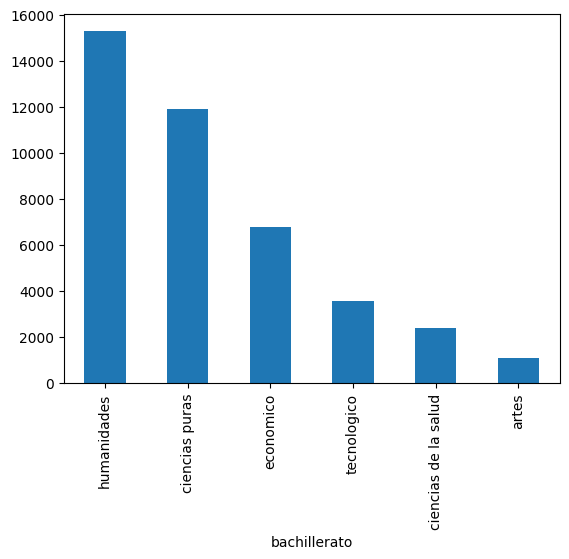

In [7]:
def limpiarString(df):
    df_limpio = df.copy()
    df_limpio = (
        df_limpio
        .astype("string")
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("ascii")
        .str.lower()
    )
    return df_limpio


def juntarBachilleratos(df):
    df_junto = df.copy()
    equivalencias = {
        "social": "humanidades",
        "ciencias sociales": "humanidades",
        "cientifico": "ciencias puras",
        "ciencias": "ciencias puras",
        "salud": "ciencias de la salud",
        "artistico": "artes"
    }
    df_junto = df_junto.replace(equivalencias)
    return df_junto


df_train["bachillerato"] = limpiarString(df_train["bachillerato"])
df_train["bachillerato"] = juntarBachilleratos(df_train["bachillerato"])

df_copy = df_train["bachillerato"]
df_copy = df_copy.value_counts()
df_copy.plot.bar()

Tenía la teoría de que la media podría diferir por bachilleratos. No es así...

*__Comentarios__*

Me la ponen como la pata de un perro envenenado ¿Me darán información relevante? 
Ahora veremos. Los separaré aprovechando que son las mismas frases siempre

Por ahora llevo estas funciones. Intentaré reutilizarlas

resumen_notas_por_bachillerato(df, columna_bachillerato, columna_nota):
juntarBachilleratos(df, columna):
limpiarCaracteres(df, columna):
contar_cadenas(df, columna):


Alumno  0 tiene  0 comentarios
Alumno  1 tiene  4 comentarios
Alumno  2 tiene  2 comentarios
Alumno  3 tiene  3 comentarios
Alumno  4 tiene  4 comentarios
Alumno  5 tiene  5 comentarios
Alumno  6 tiene  3 comentarios
Alumno  7 tiene  2 comentarios
Alumno  8 tiene  4 comentarios
Alumno  9 tiene  0 comentarios
Alumno  10 tiene  3 comentarios
Alumno  11 tiene  3 comentarios
Alumno  12 tiene  3 comentarios
Alumno  13 tiene  3 comentarios
Alumno  14 tiene  2 comentarios
Alumno  15 tiene  0 comentarios
Alumno  16 tiene  5 comentarios
Alumno  17 tiene  0 comentarios
Alumno  18 tiene  4 comentarios
Alumno  19 tiene  0 comentarios
Alumno  20 tiene  0 comentarios
Alumno  21 tiene  3 comentarios
Alumno  22 tiene  4 comentarios
Alumno  23 tiene  3 comentarios
Alumno  24 tiene  3 comentarios
Alumno  25 tiene  0 comentarios
Alumno  26 tiene  4 comentarios
Alumno  27 tiene  0 comentarios
Alumno  28 tiene  3 comentarios
Alumno  29 tiene  0 comentarios
Alumno  30 tiene  6 comentarios
Alumno  31 tiene  

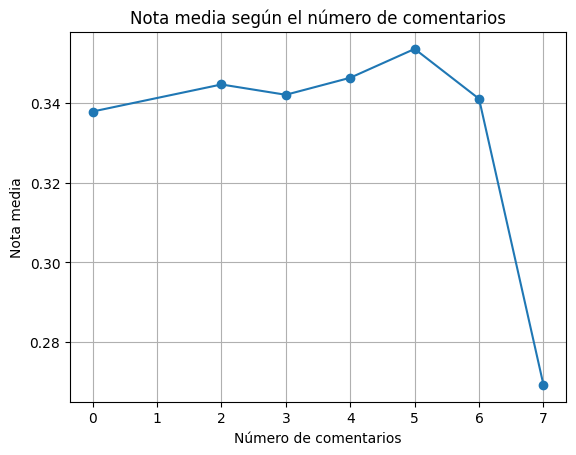

In [5]:
def contar_comentarios(df, columna): #Prueba
    num_alumno=0
    cuantos_comens={}
    for comentario in df[columna]: #Hay un punto por cada comentario del alumno
        
        total_por_alumno=0
        if isinstance(comentario, str):
            frases = comentario.strip(".").split(".")  # Separo cada frase

            for frase in frases:  # Las cuento
                total_por_alumno += 1

        print("Alumno ", num_alumno, "tiene ", total_por_alumno, "comentarios")
        if total_por_alumno in cuantos_comens:
            cuantos_comens[total_por_alumno]+=1
        else:
            cuantos_comens[total_por_alumno] = 1
        num_alumno+=1
    print("Cuantos comentarios:", cuantos_comens)
       
    



def grafico_nota_comentarios(df, columna_comentarios, columna_nota):
    comentarios_por_alumno = []
    notas = []

    for comentario, nota in zip(df[columna_comentarios], df[columna_nota]):
        total_por_alumno = 0

        if isinstance(comentario, str):
            frases = comentario.strip(".").split(".")

            for frase in frases:
                if frase.strip():
                    total_por_alumno += 1

        comentarios_por_alumno.append(total_por_alumno)
        notas.append(pd.to_numeric(str(nota).replace(",", "."), errors="coerce"))

    datos = pd.DataFrame({
        "comentarios": comentarios_por_alumno,
        "nota": notas
    })

    medias = datos.groupby("comentarios")["nota"].mean()

    plt.plot(medias.index, medias.values, marker="o")
    plt.xlabel("Número de comentarios")
    plt.ylabel("Nota media")
    plt.title("Nota media según el número de comentarios")
    plt.grid()
    plt.show()


# def separar_comentarios(df, columna):

print(contar_comentarios(df_train, "comentarios"))
#HACER FUNCIÓN QUE MUESTRA GRÁFICO DE LÍNES MOSTRANDO LA NOTA MEDIA EN COMPARACIÓN DE LOS COMENTARIOS

grafico_nota_comentarios(df_train, "comentarios", "abandono")

